In [45]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re

# Ruta raíz del proyecto
ROOT = Path(r"D:/Code/tfg-gcd")

DATA_DIR = ROOT / "Datasets"
NODOS_DIR = DATA_DIR / "Nodos"
REL_DIR = DATA_DIR / "Relaciones"
CLUSTER_DIR = DATA_DIR / "Clusterización"

# Carpeta donde guardar las figuras del análisis exploratorio
OUT_DIR = ROOT / "Datasets" / "Eda"

print("DATA_DIR existe:", DATA_DIR.exists())
print("OUT_DIR:", OUT_DIR)

COLOR_BARRAS = "#EE6666"      # rojo principal
COLOR_HIST = "#5470C6"        # azul secundario
COLOR_BORDE = "#444444"

DATA_DIR existe: True
OUT_DIR: D:\Code\tfg-gcd\Datasets\Eda


In [46]:
def read_csv_auto(path, **kwargs):
    """
    Lee un CSV probando varios encodings y separadores habituales.
    Útil para ficheros separados por coma, punto y coma o tabulador.
    """
    encodings = ["utf-8", "utf-8-sig", "latin1", "cp1252"]
    seps = [",", ";", "\t"]
    last_error = None
    
    for enc in encodings:
        for sep in seps:
            try:
                df = pd.read_csv(
                    path,
                    encoding=enc,
                    sep=sep,
                    engine="python",
                    **kwargs
                )
                
                # Evita aceptar lecturas malas con todo metido en una sola columna
                if df.shape[1] > 1:
                    print(f"Leído correctamente: {path.name} | encoding={enc} | sep={repr(sep)}")
                    return df
                
            except Exception as e:
                last_error = e
    
    raise last_error


def split_list_cell(x):
    """
    Convierte celdas tipo 'a, b, c' o listas en texto en una lista limpia.
    """
    if pd.isna(x):
        return []
    
    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]
    
    x = str(x).strip()
    if x == "" or x.lower() in {"nan", "none", "null"}:
        return []
    
    # Limpieza básica si aparece como lista textual
    x = x.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    
    parts = [p.strip() for p in re.split(r",|;", x) if p.strip()]
    return parts


def clean_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def save_fig(filename):
    path = OUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Guardado:", path)

In [47]:
investigadores = read_csv_auto(NODOS_DIR / "Investigadores_internos.csv")
areas = read_csv_auto(NODOS_DIR / "Areas.csv")
revistas = read_csv_auto(NODOS_DIR / "Revistas.csv")

print("Investigadores:", investigadores.shape)
print("Áreas:", areas.shape)
print("Revistas:", revistas.shape)

display(investigadores.head())
display(areas.head())
display(revistas.head())

Leído correctamente: Investigadores_internos.csv | encoding=latin1 | sep=';'
Leído correctamente: Areas.csv | encoding=utf-8 | sep=','
Leído correctamente: Revistas.csv | encoding=latin1 | sep=','
Investigadores: (54, 8)
Áreas: (8, 2)
Revistas: (650, 3)


,Nombre,Nombre_,Identificador,Correos,Acronimo,Tipo de empleado,Acortacion,Girado
0,Carmen Alegre Gil,Maria Carmen Alegre Gil,1,calegre@mat.upv.es,"MC Alegre Gil, C Alegre",Investigador,AlegreGC,"Alegre Gil, Maria Carmen"
1,Andrés Roger Arnau Notari,Andres Roger Arnau Notari,2,ararnnot@posgrado.upv.es,"R Arnau, AR Arnau Notari, AR Arnau-Notari",Investigador,ArnauNAR,"Arnau Notari, Andres Roger"
2,Milagros Arroyo Jordá,Milagros Arroyo Jorda,3,marroyo@mat.upv.es,"M Arroyo Jorda, Milagros Arroyo Jorda",Investigador,ArroyoJM,"Arroyo Jorda, Milagros"
3,Paz Arroyo Jordá,Paz Arroyo Jorda,4,parroyo@mat.upv.es,"P Arroyo Jorda, Paz Arroyo Jorda",Investigador,ArroyoJP,"Arroyo Jorda, Paz"
4,Vicent Asensio López,Vicent Asensio Lopez,5,viaslo@doctor.upv.es,NaN,Investigador,AsensioLV,"Asensio Lopez, Vicent"


,Area,Identificador
0,Algebra,1
1,Analisis,2
2,Becarios,3
3,Ciencia Datos,4
4,Fisica,5


,Revista,Identificador,Editorial
0,NaN,1,NaN
1,Conferencia,2,NaN
2,No indexada,3,NaN
3,AIP Advances,4,AIP Publishing
4,AIMS Mathematics,5,American Institute of Mathematical Sciences


In [48]:
es_parte_de_path = REL_DIR / "es_parte_de" / "es_parte_de_limpio_listas.csv"
es_parte_de = read_csv_auto(es_parte_de_path)

print("es_parte_de:", es_parte_de.shape)
display(es_parte_de.head())

# Detectar columnas
col_inv_area = "Nombre" if "Nombre" in es_parte_de.columns else es_parte_de.columns[0]
col_areas = "Areas" if "Areas" in es_parte_de.columns else es_parte_de.columns[1]

es_parte_de_exp = es_parte_de.copy()
es_parte_de_exp[col_areas] = es_parte_de_exp[col_areas].apply(split_list_cell)
es_parte_de_exp = es_parte_de_exp.explode(col_areas)
es_parte_de_exp[col_areas] = es_parte_de_exp[col_areas].astype(str).str.strip()
es_parte_de_exp = es_parte_de_exp[es_parte_de_exp[col_areas] != ""]

print("Relaciones investigador-área expandidas:", es_parte_de_exp.shape)
display(es_parte_de_exp.head())

Leído correctamente: es_parte_de_limpio_listas.csv | encoding=latin1 | sep=','
es_parte_de: (50, 2)


,Nombre,Areas
0,Carmen Alegre Gil,Topologia/Geometria
1,Andrés Roger Arnau Notari,"Analisis, Becarios, Ciencia Datos, Matematica ..."
2,Milagros Arroyo Jordá,Algebra
3,Paz Arroyo Jordá,Algebra
4,Vicent Asensio López,"Analisis, Becarios"


Relaciones investigador-área expandidas: (87, 2)


,Nombre,Areas
0,Carmen Alegre Gil,Topologia/Geometria
1,Andrés Roger Arnau Notari,Analisis
1,Andrés Roger Arnau Notari,Becarios
1,Andrés Roger Arnau Notari,Ciencia Datos
1,Andrés Roger Arnau Notari,Matematica aplicada


In [49]:
pub_dir = REL_DIR / "ha_publicado_en"

pub_files = sorted([
    p for p in pub_dir.glob("*.csv")
    if "Obsoleto" not in str(p) and "editoriales" in p.name
])

print("Ficheros ha_publicado_en encontrados:", len(pub_files))

publicaciones_list = []

for path in pub_files:
    df = read_csv_auto(path)
    df["fichero_origen"] = path.name
    
    # Identificador corto del investigador a partir del nombre del fichero
    inv_id = path.stem
    inv_id = inv_id.replace("1ha_publicado_en_", "").replace("_editoriales", "")
    df["investigador_id"] = inv_id
    
    publicaciones_list.append(df)

publicaciones = pd.concat(publicaciones_list, ignore_index=True) if publicaciones_list else pd.DataFrame()

# Normalización básica de columnas esperadas
publicaciones.columns = [str(c).strip() for c in publicaciones.columns]

print("Publicaciones:", publicaciones.shape)
display(publicaciones.head())
print(publicaciones.columns)

Ficheros ha_publicado_en encontrados: 42
Leído correctamente: 1ha_publicado_en_AlegreGC_editoriales.csv | encoding=utf-8 | sep=','
Leído correctamente: 1ha_publicado_en_ArnauNAR_editoriales.csv | encoding=utf-8 | sep=','
Leído correctamente: 1ha_publicado_en_ArroyoJM_editoriales.csv | encoding=utf-8 | sep=','
Leído correctamente: 1ha_publicado_en_ArroyoJP_editoriales.csv | encoding=utf-8 | sep=','
Leído correctamente: 1ha_publicado_en_BiviaC_editoriales.csv | encoding=utf-8 | sep=','
Leído correctamente: 1ha_publicado_en_BonetSJ_editoriales.csv | encoding=latin1 | sep=','
Leído correctamente: 1ha_publicado_en_CalabuigRJM_editoriales.csv | encoding=latin1 | sep=','
Leído correctamente: 1ha_publicado_en_CobolloGC_editoriales.csv | encoding=latin1 | sep=','
Leído correctamente: 1ha_publicado_en_ConejeroJA_editoriales.csv | encoding=latin1 | sep=','
Leído correctamente: 1ha_publicado_en_FelipeRMJ_editoriales.csv | encoding=utf-8 | sep=','
Leído correctamente: 1ha_publicado_en_FernandezCCPJ

,title,journal,year,fichero_origen,investigador_id
0,Characterizations of quasi metric completeness...,Hacettepe University,2017,1ha_publicado_en_AlegreGC_editoriales.csv,AlegreGC
1,Quotient subspaces of asymmetric normed linear...,NaN,2007,1ha_publicado_en_AlegreGC_editoriales.csv,AlegreGC
2,Compactness in asymmetric normed spaces,NaN,2008,1ha_publicado_en_AlegreGC_editoriales.csv,AlegreGC
3,A Caristi fixed point theorem for complete qua...,NaN,2018,1ha_publicado_en_AlegreGC_editoriales.csv,AlegreGC
4,On a class of real normed lattices,NaN,1998,1ha_publicado_en_AlegreGC_editoriales.csv,AlegreGC


Index(['title', 'journal', 'year', 'fichero_origen', 'investigador_id'], dtype='object')


In [50]:
coaut_path = REL_DIR / "ha_publicado_con" / "ha_publicado_con.csv"
ha_publicado_con = read_csv_auto(coaut_path)

print("ha_publicado_con:", ha_publicado_con.shape)
display(ha_publicado_con.head())

col_inv_coaut = "nombre" if "nombre" in ha_publicado_con.columns else ha_publicado_con.columns[0]
col_otros_coaut = "otros_inv" if "otros_inv" in ha_publicado_con.columns else ha_publicado_con.columns[1]

ha_publicado_con_exp = ha_publicado_con.copy()
ha_publicado_con_exp[col_otros_coaut] = ha_publicado_con_exp[col_otros_coaut].apply(split_list_cell)
ha_publicado_con_exp = ha_publicado_con_exp.explode(col_otros_coaut)
ha_publicado_con_exp[col_otros_coaut] = ha_publicado_con_exp[col_otros_coaut].astype(str).str.strip()
ha_publicado_con_exp = ha_publicado_con_exp[ha_publicado_con_exp[col_otros_coaut] != ""]

print("Relaciones de coautoría expandidas:", ha_publicado_con_exp.shape)
display(ha_publicado_con_exp.head())

Leído correctamente: ha_publicado_con.csv | encoding=latin1 | sep=','
ha_publicado_con: (42, 2)


,nombre,otros_inv
0,Carmen Alegre Gil,"I Ferrando, EAS Perez, C Alegre, H Dag, A Fulg..."
1,Andrés Roger Arnau Notari,"JM Calabuig, Y Wang, M Sanchis Agudo, F Estell..."
2,Milagros Arroyo Jordá,"R Dark, M Arroyo Jorda, P Arroyo Jorda, A Mart..."
3,Paz Arroyo Jordá,"AD Feldman, M Arroyo Jorda, A Martinez Pastor,..."
4,Carles Bivià Ausina,"E Ballico, L Salce, T Fukui, AF Beardon, T Din..."


Relaciones de coautoría expandidas: (3236, 2)


,nombre,otros_inv
0,Carmen Alegre Gil,I Ferrando
0,Carmen Alegre Gil,EAS Perez
0,Carmen Alegre Gil,C Alegre
0,Carmen Alegre Gil,H Dag
0,Carmen Alegre Gil,A Fulga


In [51]:
proj_dir = REL_DIR / "ha_participado_en"

proj_files = sorted([
    p for p in proj_dir.glob("*_FINAL.xlsx")
    if "Obsoleto" not in str(p)
])

print("Ficheros ha_participado_en finales encontrados:", len(proj_files))

proyectos_list = []

for path in proj_files:
    df = pd.read_excel(path)
    df["fichero_origen"] = path.name
    
    inv_id = path.stem
    inv_id = inv_id.replace("ha_participado_en_", "").replace("_FINAL", "")
    df["investigador_id"] = inv_id
    
    proyectos_list.append(df)

proyectos = pd.concat(proyectos_list, ignore_index=True) if proyectos_list else pd.DataFrame()
proyectos.columns = [str(c).strip() for c in proyectos.columns]

print("Proyectos asociados a investigadores:", proyectos.shape)
display(proyectos.head())
print(proyectos.columns)

Ficheros ha_participado_en finales encontrados: 43
Proyectos asociados a investigadores: (576, 9)


,TÍTULO,AUTORES,FECHA,INDENTIFICADOR,INVESTIGADOR PRINCIPAL,AUTORES SIMPLIFICADO,Es_IP_Principal,fichero_origen,investigador_id
0,Topologia Para Computacion: Estructuras No Sim...,"Alegre Gil, Maria Carmen (Investigador/a)",1996/09/11,PB95-0737,NaN,"Alegre Gil, Maria Carmen",True,ha_participado_en_AlegreGC_FINAL.xlsx,AlegreGC
1,"Hiperespacios, Estructuras Difusas Y Asimetric...","Tirado Pelaez, Pedro (Investigador/a); Alegre ...",2016/01/01,MTM2015-64373-P,"Rodriguez Lopez, Jesus","Tirado Pelaez, Pedro; Alegre Gil, Maria Carmen...",False,ha_participado_en_AlegreGC_FINAL.xlsx,AlegreGC
2,Metodos Topologicos En Hiperespacios Y Multifu...,"Rodriguez Lopez, Jesus (Investigador/a); Tirad...",2013/01/01,MTM2012-37894-C02-01,NaN,"Rodriguez Lopez, Jesus; Tirado Pelaez, Pedro; ...",False,ha_participado_en_AlegreGC_FINAL.xlsx,AlegreGC
3,"Integracion Bilineal, Medidas Vectoriales Y Es...","Garcia Raffi, Luis Miguel (Investigador/a); Al...",2010/01/01,MTM2009-14483-C02-02,"Sanchez Perez, Enrique Alfonso","Garcia Raffi, Luis Miguel; Alegre Gil, Maria C...",False,ha_participado_en_AlegreGC_FINAL.xlsx,AlegreGC
4,"Construcciones De Casi-Metricas Fuzzy, De Dist...","Rodriguez Lopez, Jesus (Investigador/a); Sapen...",2010/10/01,MTM2009-12872-C02-01,NaN,"Rodriguez Lopez, Jesus; Sapena Piera, Almanzor...",False,ha_participado_en_AlegreGC_FINAL.xlsx,AlegreGC


Index(['TÍTULO', 'AUTORES', 'FECHA', 'INDENTIFICADOR',
       'INVESTIGADOR PRINCIPAL', 'AUTORES SIMPLIFICADO', 'Es_IP_Principal',
       'fichero_origen', 'investigador_id'],
      dtype='object')


In [52]:
colab_proj_path = REL_DIR / "ha_participado_con" / "ha_participado_con.csv"
ha_participado_con = read_csv_auto(colab_proj_path)

print("ha_participado_con:", ha_participado_con.shape)
display(ha_participado_con.head())

col_inv_proj_colab = "nombre" if "nombre" in ha_participado_con.columns else ha_participado_con.columns[0]
col_otros_proj_colab = "otros_inv" if "otros_inv" in ha_participado_con.columns else ha_participado_con.columns[1]

ha_participado_con_exp = ha_participado_con.copy()
ha_participado_con_exp[col_otros_proj_colab] = ha_participado_con_exp[col_otros_proj_colab].apply(split_list_cell)
ha_participado_con_exp = ha_participado_con_exp.explode(col_otros_proj_colab)
ha_participado_con_exp[col_otros_proj_colab] = ha_participado_con_exp[col_otros_proj_colab].astype(str).str.strip()
ha_participado_con_exp = ha_participado_con_exp[ha_participado_con_exp[col_otros_proj_colab] != ""]

print("Relaciones de colaboración en proyectos expandidas:", ha_participado_con_exp.shape)
display(ha_participado_con_exp.head())

Leído correctamente: ha_participado_con.csv | encoding=latin1 | sep=';'
ha_participado_con: (43, 2)


,nombre,otros_inv
0,Carmen Alegre Gil,"Garcia Raffi, Luis Miguel; Morillas Gomez, Sam..."
1,Andrés Roger Arnau Notari,"Calabuig Rodriguez, Jose Manuel; Ferrer Sapena..."
2,Milagros Arroyo Jordá,"Alemany Martinez, Elena; Arroyo Jorda, Milagro..."
3,Paz Arroyo Jordá,"Alemany Martinez, Elena; Arroyo Jorda, Milagro..."
4,Vicent Asensio López,"Ariza Remacha, Hector; Asensio Lopez, Vicente;..."


Relaciones de colaboración en proyectos expandidas: (2068, 2)


,nombre,otros_inv
0,Carmen Alegre Gil,Garcia Raffi
0,Carmen Alegre Gil,Luis Miguel
0,Carmen Alegre Gil,Morillas Gomez
0,Carmen Alegre Gil,Samuel
0,Carmen Alegre Gil,Oltra Crespo


In [53]:
mat_inv_kw = pd.read_excel(CLUSTER_DIR / "Matriz_Investigadores_Keywords.xlsx")
mat_rev_kw = pd.read_excel(CLUSTER_DIR / "One_Hot_Palabras_Revistas_filtrado.xlsx")
trazabilidad_kw = pd.read_excel(CLUSTER_DIR / "Trazabilidad_Keywords_Revistas.xlsx")

json_path = CLUSTER_DIR / "Titulos_revistas.json"
with open(json_path, "r", encoding="utf-8") as f:
    titulos_revistas_json = json.load(f)

print("Matriz investigadores-keywords:", mat_inv_kw.shape)
print("Matriz revistas-keywords:", mat_rev_kw.shape)
print("Trazabilidad keywords:", trazabilidad_kw.shape)
print("Titulos_revistas.json:", type(titulos_revistas_json))

display(mat_inv_kw.head())
display(mat_rev_kw.head())
display(trazabilidad_kw.head())

Matriz investigadores-keywords: (42, 104)
Matriz revistas-keywords: (643, 104)
Trazabilidad keywords: (9591, 3)
Titulos_revistas.json: <class 'list'>


,Investigador,Spain,academic,acoustics,algebra,algorithms,analysis,applications,applied,biology,...,studies,systems,teaching,technology,theoretical,theory,topology,treatment,university,vision
0,AlegreGC,0,1,0,1,0,1,1,1,0,...,0,1,1,0,0,1,1,0,0,0
1,ArnauNAR,1,1,0,1,0,1,1,1,0,...,0,0,0,1,0,1,1,0,1,0
2,ArroyoJM,1,1,0,1,0,1,1,1,0,...,0,0,0,0,0,1,0,0,0,0
3,ArroyoJP,1,1,0,1,0,1,1,1,0,...,0,0,0,0,0,1,0,0,0,0
4,BiviaC,1,1,0,1,1,1,1,1,0,...,0,0,0,1,0,1,1,0,1,0


,-,Spain,academic,acoustics,algebra,algorithms,analysis,applications,applied,biology,...,studies,systems,teaching,technology,theoretical,theory,topology,treatment,university,vision
0,NaN,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Conferencia,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,No indexada,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AIP Advances,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,AIMS Mathematics,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0


,Investigador,Revista,Keyword
0,AlegreGC,Hacettepe University,academic
1,AlegreGC,Hacettepe University,education
2,AlegreGC,Hacettepe University,faculty
3,AlegreGC,Hacettepe University,research
4,AlegreGC,Hacettepe University,science


# Tabla resumen

In [54]:
# Columnas esperadas en publicaciones
col_title = "title" if "title" in publicaciones.columns else None
col_journal = "journal" if "journal" in publicaciones.columns else None

# Columnas esperadas en proyectos
col_titulo_proy = "TÍTULO" if "TÍTULO" in proyectos.columns else ("TITULO" if "TITULO" in proyectos.columns else None)

# Conteos bibliográficos
num_articulos = publicaciones[col_title].dropna().astype(str).str.strip().replace("", np.nan).dropna().shape[0] if col_title else len(publicaciones)
num_revistas_en_publicaciones = publicaciones[col_journal].dropna().astype(str).str.strip().nunique() if col_journal else np.nan

# Proyectos únicos por título
num_proyectos_unicos = proyectos[col_titulo_proy].dropna().astype(str).str.strip().nunique() if col_titulo_proy else np.nan

# Editoriales
col_editorial = "Editorial" if "Editorial" in revistas.columns else None
num_editoriales = revistas[col_editorial].dropna().astype(str).str.strip().replace("", np.nan).dropna().nunique() if col_editorial else np.nan

# Keywords
# Se asume que la primera columna identifica investigador/revista, y el resto son palabras clave
num_keywords_inv = max(mat_inv_kw.shape[1] - 1, 0)
num_keywords_rev = max(mat_rev_kw.shape[1] - 1, 0)



tabla_resumen = pd.DataFrame({
    "Elemento": [
        "Investigadores internos",
        "Áreas de trabajo",
        "Revistas",
        "Editoriales asociadas a revistas",
        "Artículos recopilados",
        "Revistas presentes en publicaciones",
        "Proyectos únicos",
        "Relaciones investigador-área",
        "Relaciones investigador-revista/artículo",
        "Relaciones investigador-proyecto",
        "Relaciones de coautoría",
        "Relaciones de colaboración en proyectos",
        "Palabras clave únicas en matriz de investigadores",
        "Revistas con representación temática",
        "Investigadores con representación temática"
    ],
    "Valor": [
        len(investigadores),
        len(areas),
        len(revistas),
        num_editoriales,
        num_articulos,
        num_revistas_en_publicaciones,
        num_proyectos_unicos,
        len(es_parte_de_exp),
        len(publicaciones),
        len(proyectos),
        len(ha_publicado_con_exp),
        len(ha_participado_con_exp),
        num_keywords_inv,
        len(mat_rev_kw),
        len(mat_inv_kw)
    ]
})
# Cobertura por investigador
investigadores_con_publicaciones = publicaciones["investigador_id"].nunique()
investigadores_con_proyectos = proyectos["investigador_id"].nunique()
investigadores_con_areas = es_parte_de_exp[col_inv_area].nunique()

filas_extra = pd.DataFrame({
    "Elemento": [
        "Investigadores con publicaciones recopiladas",
        "Investigadores con proyectos asociados",
        "Investigadores con áreas asociadas"
    ],
    "Valor": [
        investigadores_con_publicaciones,
        investigadores_con_proyectos,
        investigadores_con_areas
    ]
})

tabla_resumen = pd.concat([tabla_resumen, filas_extra], ignore_index=True)

display(tabla_resumen)

tabla_resumen.to_csv(OUT_DIR / "eda_tabla_resumen.csv", index=False, encoding="utf-8-sig")
print("Guardado:", OUT_DIR / "eda_tabla_resumen.csv")

,Elemento,Valor
0,Investigadores internos,54
1,Áreas de trabajo,8
2,Revistas,650
3,Editoriales asociadas a revistas,269
4,Artículos recopilados,4318
5,Revistas presentes en publicaciones,647
6,Proyectos únicos,281
7,Relaciones investigador-área,87
8,Relaciones investigador-revista/artículo,4318
9,Relaciones investigador-proyecto,576


Guardado: D:\Code\tfg-gcd\Datasets\Eda\eda_tabla_resumen.csv


# Distribución de investigadores por tipo de empleado

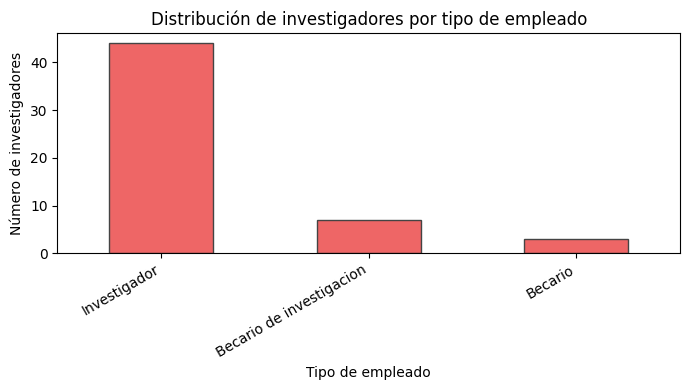

Guardado: D:\Code\tfg-gcd\Datasets\Eda\eda_tipo_empleado.png


Tipo de empleado
Investigador                44
Becario de investigacion     7
Becario                      3
Name: count, dtype: int64

In [55]:
tipo_col = "Tipo de empleado"

if tipo_col not in investigadores.columns:
    print("Columnas disponibles:", investigadores.columns)
    raise ValueError("No encuentro la columna 'Tipo de empleado'. Ajusta tipo_col.")

tipo_counts = (
    investigadores[tipo_col]
    .fillna("No disponible")
    .astype(str)
    .str.strip()
    .value_counts()
)

plt.figure(figsize=(7, 4))
tipo_counts.plot(kind="bar", color=COLOR_BARRAS, edgecolor=COLOR_BORDE)
plt.xlabel("Tipo de empleado")
plt.ylabel("Número de investigadores")
plt.title("Distribución de investigadores por tipo de empleado")
plt.xticks(rotation=30, ha="right")
save_fig("eda_tipo_empleado.png")

display(tipo_counts)

# Investigadores asociados a cada área

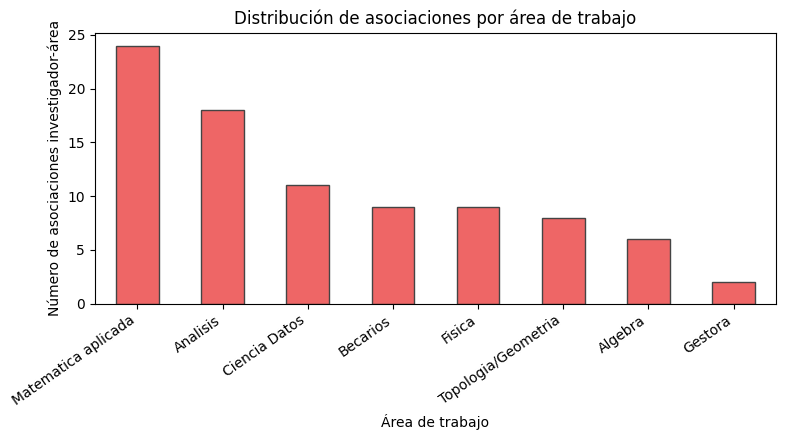

Guardado: D:\Code\tfg-gcd\Datasets\Eda\eda_areas_trabajo.png


Areas
Matematica aplicada    24
Analisis               18
Ciencia Datos          11
Becarios                9
Fisica                  9
Topologia/Geometria     8
Algebra                 6
Gestora                 2
Name: count, dtype: int64

In [56]:
area_counts = (
    es_parte_de_exp[col_areas]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4.5))
area_counts.plot(kind="bar", color=COLOR_BARRAS, edgecolor=COLOR_BORDE)
plt.xlabel("Área de trabajo")
plt.ylabel("Número de asociaciones investigador-área")
plt.title("Distribución de asociaciones por área de trabajo")
plt.xticks(rotation=35, ha="right")
save_fig("eda_areas_trabajo.png")

display(area_counts)

# Distribución de artículos por investigador

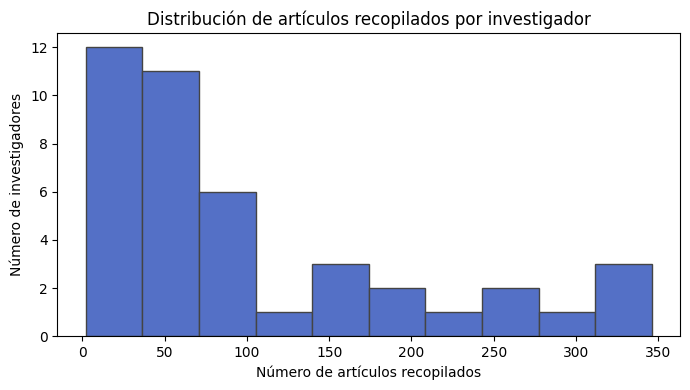

Guardado: D:\Code\tfg-gcd\Datasets\Eda\eda_articulos_por_investigador.png


count     42.000000
mean     102.809524
std      100.598026
min        2.000000
25%       31.500000
50%       54.500000
75%      153.250000
max      346.000000
Name: num_articulos, dtype: float64

In [57]:
articulos_por_inv = (
    publicaciones
    .groupby("investigador_id")
    .size()
    .rename("num_articulos")
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.hist(articulos_por_inv["num_articulos"], bins=10, color=COLOR_HIST, edgecolor=COLOR_BORDE)
plt.xlabel("Número de artículos recopilados")
plt.ylabel("Número de investigadores")
plt.title("Distribución de artículos recopilados por investigador")
save_fig("eda_articulos_por_investigador.png")

display(articulos_por_inv["num_articulos"].describe())

# Distribución de revistas distintas por investigador

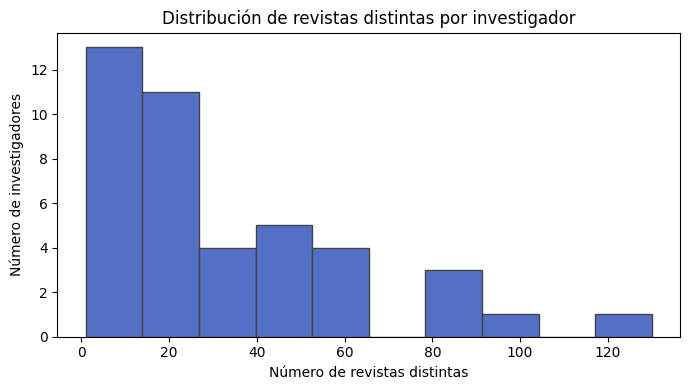

Guardado: D:\Code\tfg-gcd\Datasets\Eda\eda_revistas_por_investigador.png


count     42.000000
mean      33.047619
std       29.999148
min        1.000000
25%       10.250000
50%       25.000000
75%       48.750000
max      130.000000
Name: num_revistas_distintas, dtype: float64

In [58]:
if col_journal is None:
    raise ValueError("No encuentro columna de revista en publicaciones.")

revistas_por_inv = (
    publicaciones
    .dropna(subset=[col_journal])
    .assign(journal_clean=lambda d: d[col_journal].astype(str).str.strip())
    .groupby("investigador_id")["journal_clean"]
    .nunique()
    .rename("num_revistas_distintas")
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.hist(revistas_por_inv["num_revistas_distintas"], bins=10, color=COLOR_HIST, edgecolor=COLOR_BORDE)
plt.xlabel("Número de revistas distintas")
plt.ylabel("Número de investigadores")
plt.title("Distribución de revistas distintas por investigador")
save_fig("eda_revistas_por_investigador.png")

display(revistas_por_inv["num_revistas_distintas"].describe())

# Distribución de proyectos por investigador

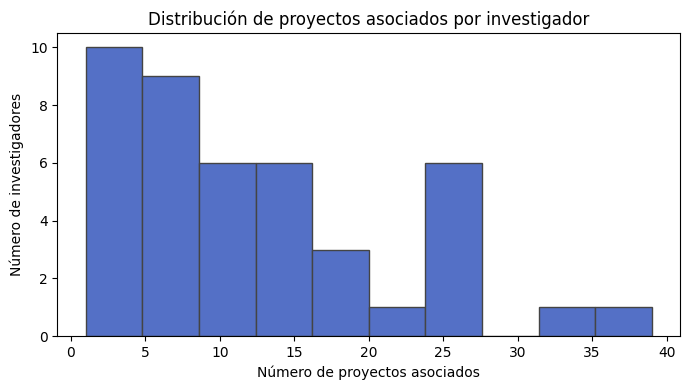

Guardado: D:\Code\tfg-gcd\Datasets\Eda\eda_proyectos_por_investigador.png


count    43.000000
mean     12.186047
std       9.464862
min       1.000000
25%       5.000000
50%       9.000000
75%      17.000000
max      39.000000
Name: num_proyectos, dtype: float64

In [59]:
if col_titulo_proy is None:
    raise ValueError("No encuentro columna de título de proyecto.")

proyectos_por_inv = (
    proyectos
    .dropna(subset=[col_titulo_proy])
    .assign(proyecto_clean=lambda d: d[col_titulo_proy].astype(str).str.strip())
    .groupby("investigador_id")["proyecto_clean"]
    .nunique()
    .rename("num_proyectos")
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.hist(proyectos_por_inv["num_proyectos"], bins=10, color=COLOR_HIST, edgecolor=COLOR_BORDE)
plt.xlabel("Número de proyectos asociados")
plt.ylabel("Número de investigadores")
plt.title("Distribución de proyectos asociados por investigador")
save_fig("eda_proyectos_por_investigador.png")

display(proyectos_por_inv["num_proyectos"].describe())

# Investigadores por proyecto

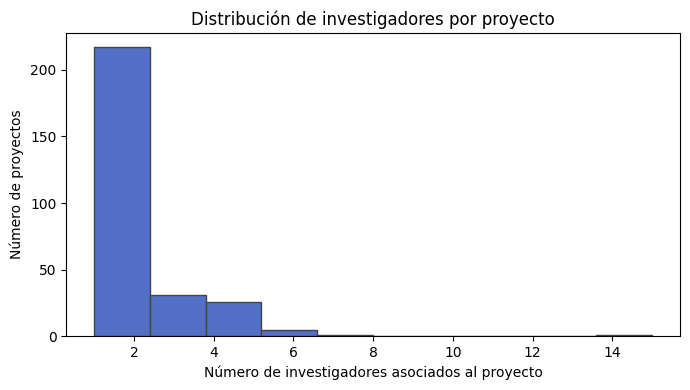

Guardado: D:\Code\tfg-gcd\Datasets\Eda\eda_investigadores_por_proyecto.png


count    281.000000
mean       1.864769
std        1.447734
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       15.000000
Name: num_investigadores, dtype: float64

In [60]:
investigadores_por_proyecto = (
    proyectos
    .dropna(subset=[col_titulo_proy])
    .assign(proyecto_clean=lambda d: d[col_titulo_proy].astype(str).str.strip())
    .groupby("proyecto_clean")["investigador_id"]
    .nunique()
    .rename("num_investigadores")
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.hist(investigadores_por_proyecto["num_investigadores"], bins=10, color=COLOR_HIST, edgecolor=COLOR_BORDE)
plt.xlabel("Número de investigadores asociados al proyecto")
plt.ylabel("Número de proyectos")
plt.title("Distribución de investigadores por proyecto")
save_fig("eda_investigadores_por_proyecto.png")

display(investigadores_por_proyecto["num_investigadores"].describe())

# Tabla de cobertura semántica

In [61]:
# Primera columna como identificador y resto como palabras clave
inv_kw_values = mat_inv_kw.iloc[:, 1:]
rev_kw_values = mat_rev_kw.iloc[:, 1:]

# Densidad: proporción de unos respecto al total de celdas binarias
densidad_inv_kw = (inv_kw_values == 1).sum().sum() / inv_kw_values.size
densidad_rev_kw = (rev_kw_values == 1).sum().sum() / rev_kw_values.size

tabla_semantica = pd.DataFrame({
    "Elemento": [
        "Investigadores con representación temática",
        "Revistas con representación temática",
        "Palabras clave únicas en matriz de investigadores",
        "Palabras clave únicas en matriz de revistas",
        "Relaciones investigador-palabra clave activas",
        "Relaciones revista-palabra clave activas",
        "Densidad matriz investigador-palabra clave",
        "Densidad matriz revista-palabra clave"
    ],
    "Valor": [
        len(mat_inv_kw),
        len(mat_rev_kw),
        mat_inv_kw.shape[1] - 1,
        mat_rev_kw.shape[1] - 1,
        int((inv_kw_values == 1).sum().sum()),
        int((rev_kw_values == 1).sum().sum()),
        round(densidad_inv_kw, 4),
        round(densidad_rev_kw, 4)
    ]
})

display(tabla_semantica)

tabla_semantica.to_csv(OUT_DIR / "eda_tabla_cobertura_semantica.csv", index=False, encoding="utf-8-sig")
print("Guardado:", OUT_DIR / "eda_tabla_cobertura_semantica.csv")

,Elemento,Valor
0,Investigadores con representación temática,42.0000
1,Revistas con representación temática,643.0000
2,Palabras clave únicas en matriz de investigadores,103.0000
3,Palabras clave únicas en matriz de revistas,103.0000
4,Relaciones investigador-palabra clave activas,1916.0000
5,Relaciones revista-palabra clave activas,4410.0000
6,Densidad matriz investigador-palabra clave,0.4429
7,Densidad matriz revista-palabra clave,0.0666


Guardado: D:\Code\tfg-gcd\Datasets\Eda\eda_tabla_cobertura_semantica.csv


# Tabla de estadísticas descriptivas

In [62]:
estadisticas = pd.DataFrame({
    "Variable": [
        "Artículos por investigador",
        "Revistas distintas por investigador",
        "Proyectos por investigador",
        "Investigadores por proyecto",
        "Áreas por investigador"
    ],
    "Media": [
        articulos_por_inv["num_articulos"].mean(),
        revistas_por_inv["num_revistas_distintas"].mean(),
        proyectos_por_inv["num_proyectos"].mean(),
        investigadores_por_proyecto["num_investigadores"].mean(),
        es_parte_de_exp.groupby(col_inv_area)[col_areas].nunique().mean()
    ],
    "Mediana": [
        articulos_por_inv["num_articulos"].median(),
        revistas_por_inv["num_revistas_distintas"].median(),
        proyectos_por_inv["num_proyectos"].median(),
        investigadores_por_proyecto["num_investigadores"].median(),
        es_parte_de_exp.groupby(col_inv_area)[col_areas].nunique().median()
    ],
    "Mínimo": [
        articulos_por_inv["num_articulos"].min(),
        revistas_por_inv["num_revistas_distintas"].min(),
        proyectos_por_inv["num_proyectos"].min(),
        investigadores_por_proyecto["num_investigadores"].min(),
        es_parte_de_exp.groupby(col_inv_area)[col_areas].nunique().min()
    ],
    "Máximo": [
        articulos_por_inv["num_articulos"].max(),
        revistas_por_inv["num_revistas_distintas"].max(),
        proyectos_por_inv["num_proyectos"].max(),
        investigadores_por_proyecto["num_investigadores"].max(),
        es_parte_de_exp.groupby(col_inv_area)[col_areas].nunique().max()
    ]
})

estadisticas = estadisticas.round(2)

display(estadisticas)

estadisticas.to_csv(OUT_DIR / "eda_tabla_estadisticas.csv", index=False, encoding="utf-8-sig")
print("Guardado:", OUT_DIR / "eda_tabla_estadisticas.csv")

,Variable,Media,Mediana,Mínimo,Máximo
0,Artículos por investigador,102.81,54.5,2,346
1,Revistas distintas por investigador,33.05,25.0,1,130
2,Proyectos por investigador,12.19,9.0,1,39
3,Investigadores por proyecto,1.86,1.0,1,15
4,Áreas por investigador,1.74,2.0,1,4


Guardado: D:\Code\tfg-gcd\Datasets\Eda\eda_tabla_estadisticas.csv
